<a href="https://colab.research.google.com/github/souhaib-coder/souhaib-coder/blob/main/RegressionLineaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
x,y=make_regression(n_samples=100,n_features=1,noise=10)

In [3]:
y=y.reshape(y.shape[0],1)

In [4]:
def linear_model(x,theta):
  return np.dot(x,theta)

In [5]:
X=np.hstack((x,np.ones((x.shape[0],1))))
X.shape

(100, 2)

In [6]:
theta=np.random.randn(x.shape[1]+1,1)
f=linear_model(X,theta)

In [7]:
def visualisation(x, y, model):
    plt.scatter(x, y, label="Données réelles")
    plt.plot(x, model, color="red", label="Modèle")
    plt.legend()
    plt.title("Régression linéaire")
    plt.show()


Visualisation du model avant l'optimisation

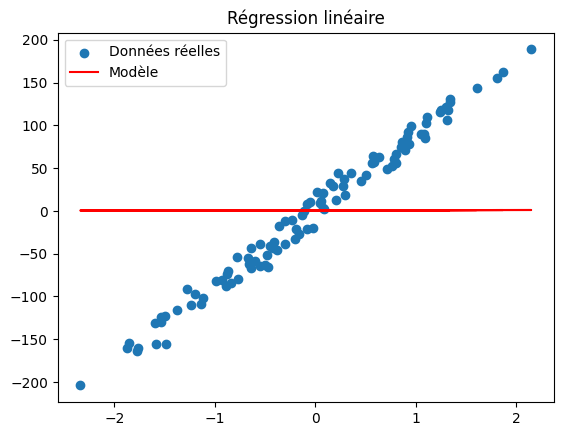

In [8]:
visualisation(x,y,f)

In [9]:
def costFunction(estimated_y,y):
  n=y.shape[0]
  res=y-estimated_y
  return (1/(2*n)) * np.dot(res.T, res)


In [10]:
def grad(X,y,theta):
  n=X.shape[0]
  return (1/n)*np.dot(X.T,(linear_model(X,theta))-y)

In [11]:
def gradient(X,y,theta,learningRate,nIteration):
  cost_history = np.zeros(nIteration)
  for i in range(nIteration):
    cost_history[i] = costFunction(linear_model(X, theta), y)
    g=grad(X,y,theta)
    theta=theta-learningRate*g
  return theta, cost_history

In [12]:
nombre_iteration=100
learningRate=0.2
optimume_theta,cost=gradient(X,y,theta,learningRate,nombre_iteration)

/tmp/ipython-input-305868158.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cost_history[i] = costFunction(linear_model(X, theta), y)


In [13]:
costFunction(np.dot(X,optimume_theta),y)

array([[56.41269905]])

In [14]:
def plot_cost_function(nombre_iteration,cost):
  plt.plot(range(nombre_iteration),cost)
  plt.xlabel("iteration")
  plt.ylabel("J(theta)")

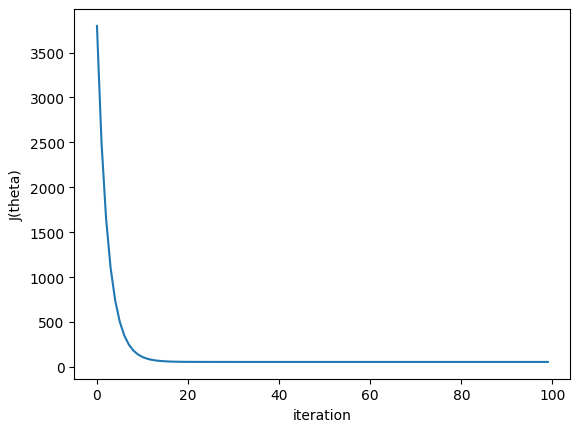

In [15]:
plot_cost_function(nombre_iteration,cost)

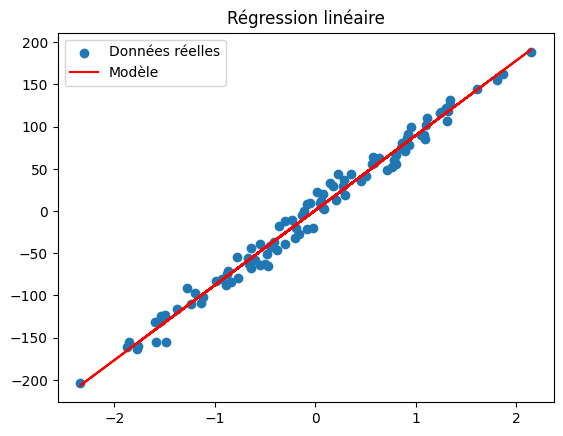

In [16]:
optimume_model=linear_model(X,optimume_theta)
visualisation(x,y,optimume_model)

In [17]:
def coef_determination(y, pred):
    u = ((y - pred)**2).sum()
    v = ((y - y.mean())**2).sum()
    return 1 - u/v

In [18]:
coef_determination(y,optimume_model)*100

np.float64(98.51458028912585)

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

print("=== LinearRegression scikit-learn ===")
print(f"Intercept : {lr.intercept_}")
print(f"Coefficients : {lr.coef_}")
print(f"R² : {lr.score(X, y)*100}%")

=== LinearRegression scikit-learn ===
Intercept : [0.82296082]
Coefficients : [[88.6115787  0.       ]]
R² : 98.51458028912585%


This cell imports the necessary libraries for linear regression: `numpy` for numerical operations and `LinearRegression` from `sklearn.linear_model`. It then defines two NumPy arrays, `xi` and `yi`, representing the input features and target variable respectively. A `LinearRegression` model is initialized and trained on the data. The code then calculates and prints the coefficient of determination (R-squared), the intercept, and the coefficients of the fitted model. Finally, it makes a prediction using a new data point `valeur_x` and prints the predicted value.

In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression


xi = np.array([
    [100000, 2021, 2, 0],
    [50000, 2023, 1, 0],
    [300000, 2012, 3, 1],
    [10000, 2024, 1, 0],
    [14000, 2023, 2, 1],
    [70000, 2021, 5, 1]
])
yi = np.array([350000, 500000, 100000, 600000, 350000, 250000])

print(xi)
print(yi)

lineaire = LinearRegression()
lineaire.fit(xi, yi)

r_sq = lineaire.score(xi, yi)
print(f"Coefficient of determination : {r_sq}")

print(f"Intercept : {lineaire.intercept_}")
print(f"Coefficients : {lineaire.coef_}")


valeur_x = np.array([[50000, 2019, 4, 0]])
valeur_y = lineaire.predict(valeur_x)
print(f"Prediction : {valeur_y}")

[[100000   2021      2      0]
 [ 50000   2023      1      0]
 [300000   2012      3      1]
 [ 10000   2024      1      0]
 [ 14000   2023      2      1]
 [ 70000   2021      5      1]]
[350000 500000 100000 600000 350000 250000]
Coefficient of determination : 0.962925727735737
Intercept : 352739066.72389734
Coefficients : [-7.60459129e+00 -1.73940142e+05 -2.04215834e+04 -3.37107917e+05]
Prediction : [1092004.93457186]


This cell imports the necessary libraries for generating and visualizing regression data: `numpy` for numerical operations, `make_regression` from `sklearn.datasets` to generate synthetic regression data, `matplotlib.pyplot` for plotting, and `pandas` for data manipulation (although not used in this specific cell).

In [21]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import pandas as pd

This cell generates synthetic regression data using `make_regression`. It creates 100 samples (`n_samples=100`) with one feature (`n_features=1`) and adds a noise level of 10 (`noise=10`). The generated features are stored in `x` and the target variable in `y`.

In [22]:
x,y=make_regression(n_samples=100,n_features=1,noise=10)

This cell reshapes the target variable `y` into a column vector. This is often required for matrix operations in linear regression.

In [23]:
y=y.reshape(y.shape[0],1)

This cell defines a function `linear_model` that calculates the predicted values based on the input features `x` and the model parameters `theta`. It performs a dot product of `x` and `theta`, which is the core of the linear regression model.

In [24]:
def linear_model(x,theta):
  return np.dot(x,theta)

This cell prepares the input features `X` for the linear regression model by adding a column of ones to the original feature matrix `x`. This column of ones represents the intercept term in the linear equation. The shape of the resulting `X` matrix is then printed.

In [25]:
X=np.hstack((x,np.ones((x.shape[0],1))))
X.shape

(100, 2)

This cell initializes the model parameters `theta` with random values using `np.random.randn`. The shape of `theta` is (2, 1) because we have one feature and an intercept term. It then calculates the initial predictions `f` using the `linear_model` function with the initial `X` and `theta`.

In [26]:
theta=np.random.randn(2,1)
f=linear_model(X,theta)

This cell defines a function `visualisation` to plot the real data points and the linear model's predictions. It takes the original features `x`, the real target variable `y`, and the model's predictions `model` as input. It uses `matplotlib.pyplot` to create a scatter plot of the real data and a line plot of the model's predictions.

In [27]:
def visualisation(x, y, model):
    plt.scatter(x, y, label="Données réelles")
    plt.plot(x, model, color="red", label="Modèle")
    plt.legend()
    plt.title("Régression linéaire")
    plt.show()

This cell calls the `visualisation` function to plot the initial state of the linear model before optimization. It shows how well the randomly initialized model fits the data.

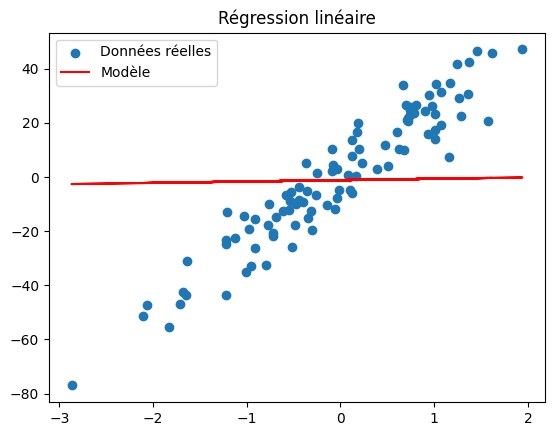

In [28]:
visualisation(x,y,f)

This cell defines the `costFunction` which calculates the mean squared error between the estimated target values (`estimated_y`) and the actual target values (`y`). This function is used to quantify the performance of the linear model.

In [29]:
def costFunction(estimated_y,y):
  n=y.shape[0]
  res=y-estimated_y
  return (1/(2*n)) * np.dot(res.T, res)

This cell defines the `grad` function, which calculates the gradient of the cost function with respect to the model parameters `theta`. The gradient indicates the direction of the steepest ascent of the cost function, and we move in the opposite direction to minimize it during gradient descent.

In [30]:
def grad(X,y,theta):
  n=X.shape[0]
  return (1/n)*np.dot(X.T,(linear_model(X,theta))-y)

This cell defines the `gradient` function, which implements the gradient descent algorithm to optimize the model parameters `theta`. It iteratively updates `theta` by subtracting the product of the learning rate and the gradient. It also records the cost function value at each iteration to track the optimization progress.

In [31]:
def gradient(X,y,theta,learningRate,nIteration):
  cost_history = np.zeros(nIteration)
  for i in range(nIteration):
    cost_history[i] = costFunction(linear_model(X, theta), y)
    g=grad(X,y,theta)
    theta=theta-learningRate*g
  return theta, cost_history

This cell sets the number of iterations (`nombre_iteration`) and the learning rate (`learningRate`) for the gradient descent algorithm. It then calls the `gradient` function to perform the optimization and obtains the optimized model parameters (`optimume_theta`) and the history of the cost function values (`cost`).

In [32]:
nombre_iteration=100
learningRate=0.2
optimume_theta,cost=gradient(X,y,theta,learningRate,nombre_iteration)

/tmp/ipython-input-305868158.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cost_history[i] = costFunction(linear_model(X, theta), y)


This cell calculates the final cost function value using the optimized model parameters `optimume_theta`. This value represents the minimum cost achieved after the gradient descent optimization.

In [33]:
costFunction(np.dot(X,optimume_theta),y)

array([[30.27319531]])

This cell defines a function `plot_cost_function` to visualize the cost function's history during the gradient descent optimization. It plots the cost value against the number of iterations, showing how the cost decreased over time.

In [34]:
def plot_cost_function(nombre_iteration,cost):
  plt.plot(range(nombre_iteration),cost)
  plt.xlabel("iteration")
  plt.ylabel("J(theta)")

This cell calls the `plot_cost_function` to display the plot of the cost function history.

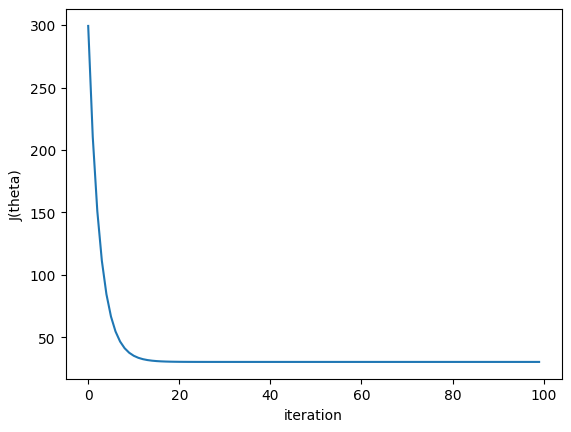

In [35]:
plot_cost_function(nombre_iteration,cost)

This cell calculates the predictions using the optimized model parameters `optimume_theta` and calls the `visualisation` function to plot the optimized linear model along with the real data points. This visualization shows how well the optimized model fits the data.

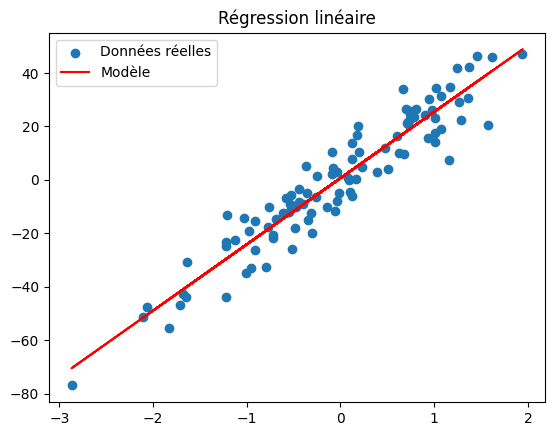

In [36]:
optimume_model=linear_model(X,optimume_theta)
visualisation(x,y,optimume_model)

This cell defines the `coef_determination` function to calculate the coefficient of determination (R-squared) of the model. R-squared is a statistical measure that represents the proportion of the variance in the dependent variable that is predictable from the independent variables.

In [37]:
def coef_determination(y, pred):
    u = ((y - pred)**2).sum()
    v = ((y - y.mean())**2).sum()
    return 1 - u/v

This cell calculates and prints the coefficient of determination (R-squared) of the optimized model, multiplied by 100 to express it as a percentage.

In [38]:
coef_determination(y,optimume_model)*100

np.float64(90.23544518440055)

This cell demonstrates how to perform linear regression using the `LinearRegression` class from the `sklearn.linear_model` module. It fits a linear regression model to the data and then prints the intercept, coefficients, and the R-squared value obtained from the scikit-learn model. This allows for comparison with the custom gradient descent implementation.

In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

print("=== LinearRegression scikit-learn ===")
print(f"Intercept : {lr.intercept_}")
print(f"Coefficients : {lr.coef_}")
print(f"R² : {lr.score(X, y)*100}%")

=== LinearRegression scikit-learn ===
Intercept : [0.63854536]
Coefficients : [[24.79517622  0.        ]]
R² : 90.23544518440055%
